# Out-of-core depression filling

DEMs larger than RAM can't be filled whole-array. `digital-rivers` adds an `engine=` switch to
`DEM.fill_depressions` that streams the **Barnes 2016 tiled master-graph** fill to disk one tile at a
time — with **constant memory** and a result that is **bit-for-bit identical** to the in-memory fill
(for `epsilon = 0`).

- `engine="in_memory"` — the classic whole-array path.
- `engine="tiled"` — out-of-core; requires `out_path` (streams to disk).
- `engine="auto"` (default) — in-memory unless the raster is large enough to risk exhausting RAM.

In [1]:
import matplotlib.pyplot as plt
# keep the executed notebook small
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80

## Setup — fetch a real DEM (Mount Hood, SRTM 1″)

In [2]:
import gzip, os, shutil, tempfile, urllib.request
from pathlib import Path

import numpy as np
from pyramids.dataset import Dataset
from digitalrivers import DEM


def _data_dir() -> Path:
    """Cache downloads under <project>/examples/data/ (project root marked by pyproject.toml)."""
    cwd = Path.cwd().resolve()
    for parent in (cwd, *cwd.parents):
        if (parent / "pyproject.toml").exists():
            d = parent / "examples" / "data"
            d.mkdir(parents=True, exist_ok=True)
            return d
    d = cwd / "data"
    d.mkdir(exist_ok=True)
    return d


# Download a real 1-arc-second SRTM tile (AWS open data, no auth), cached locally.
DATA = _data_dir()
hgt, gz = DATA / "N45W122.hgt", DATA / "N45W122.hgt.gz"
URL = "https://elevation-tiles-prod.s3.amazonaws.com/skadi/N45/N45W122.hgt.gz"
if not hgt.exists():
    if not gz.exists():
        print(f"Downloading {URL} ...")
        urllib.request.urlretrieve(URL, gz)
    with gzip.open(gz, "rb") as fi, open(hgt, "wb") as fo:
        shutil.copyfileobj(fi, fo)

# Crop a ~0.1 degree (360x360) window around Mount Hood and save it as a file-backed GeoTIFF DEM.
raw = np.fromfile(hgt, dtype=">i2").reshape(3601, 3601).astype(np.float32)
crop = raw[940:1300, 1080:1440].copy()
WORK = Path(tempfile.mkdtemp(prefix="dr_ooc_"))
DEM_PATH = WORK / "mt_hood_dem.tif"
Dataset.create_from_array(
    crop, top_left_corner=(-121.9, 45.5), cell_size=1 / 3600, epsg=4326,
    no_data_value=-32768.0, driver_type="GTiff", path=str(DEM_PATH),
).close()
dem = DEM(Dataset.read_file(str(DEM_PATH)).raster)
print(f"DEM: {dem.rows} x {dem.columns} cells, elevation {crop.min():.0f}-{crop.max():.0f} m")

2026-06-09 00:18:02 | INFO | pyramids.base.config | Logging is configured.


DEM: 360 x 360 cells, elevation 23-1195 m


## Tiled vs in-memory fill
We force `engine="tiled"` with a small `tile_size` so the 360×360 DEM is split into many tiles (depressions straddle the seams), then check the result equals the whole-array fill exactly.

In [3]:
in_mem = dem.fill_depressions(engine="in_memory")
tiled = dem.fill_depressions(
    engine="tiled", out_path=str(WORK / "filled_tiled.tif"), tile_size=128
)
a = np.asarray(in_mem.read_array())
b = np.asarray(tiled.read_array())
print("tiled fill == in-memory fill (bit-for-bit):", np.array_equal(a, b))

tiled fill == in-memory fill (bit-for-bit): True


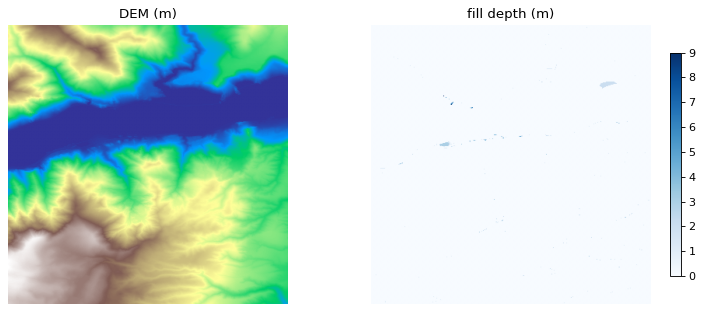

In [4]:
elev = np.asarray(dem.read_array())
pits = np.asarray(in_mem.read_array()) - elev  # how much each cell was raised
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(elev, cmap="terrain"); ax[0].set_title("DEM (m)")
im = ax[1].imshow(pits, cmap="Blues"); ax[1].set_title("fill depth (m)")
fig.colorbar(im, ax=ax[1], shrink=0.8); [a.axis("off") for a in ax]
fig.tight_layout()

## The `auto` heuristic
`auto` estimates the per-stage peak memory and only switches to the tiled engine when it would exceed a safety fraction of available RAM. This small DEM stays in-memory; a continental one would flip to tiled.

In [5]:
from digitalrivers._outofcore.engine import resolve_engine
print("360x360  ->", resolve_engine("auto", 360, 360))
print("60k x 60k ->", resolve_engine("auto", 60000, 60000, available_bytes=8 * 10**9))

360x360  -> in_memory
60k x 60k -> tiled


## `epsilon > 0` fill (flat removal)
`epsilon > 0` tilts filled flats so every cell drains (no plateaus). For `epsilon > 0` the tiled engine uses the
exit-distance ramp (`eps_fill="exact"`, the default — alias `"monotone"`), which is **byte-for-byte identical**
to the in-memory fill and flat-free for *small* `epsilon`. For a guaranteed flat-free surface at *any* `epsilon`,
use `engine="in_memory"` with `eps_fill="barnes"` (the classic Priority-Flood step-count, in-memory only). See
the **Epsilon-fill modes** example for the full comparison.

In [6]:
ramp = dem.fill_depressions(
    engine="tiled", out_path=str(WORK / "filled_eps.tif"), tile_size=128, epsilon=1e-3
)
in_mem_eps = dem.fill_depressions(engine="in_memory", epsilon=1e-3)
surf = np.asarray(ramp.read_array())

# eps_fill="exact" (default): the tiled epsilon ramp is byte-for-byte identical to the in-memory fill.
print(
    "tiled epsilon fill == in-memory (bit-for-bit):",
    np.array_equal(surf, np.asarray(in_mem_eps.read_array())),
)


def interior_flats(s):
    flats = 0
    for i in range(1, s.shape[0] - 1):
        for j in range(1, s.shape[1] - 1):
            if not (s[i - 1 : i + 2, j - 1 : j + 2] < s[i, j]).any():
                flats += 1
    return flats


print("interior flats after eps=0 fill        :", interior_flats(a))
print("interior flats after epsilon=1e-3 fill :", interior_flats(surf))

tiled epsilon fill == in-memory (bit-for-bit): True


interior flats after eps=0 fill        : 17179


interior flats after epsilon=1e-3 fill : 0


In [7]:
for d in (in_mem, tiled, ramp, in_mem_eps):
    d.close()